# Representation of signals & inverse problems - G1-G2

## Lab session 4: Gradient descent

## Guidelines (read carefully before starting)

**Objective:** this lab is divided into two parts. The first part summarizes the theoretical notions used throughout this lab, and does not contain any question. The second part contains 3 exercises, which will guide you through the following
1. introduction to gradient descent on a toy example;
2. image denoising with the gradient descent;
3. image inpainting with the projected gradient descent.

**Guidelines:** after retrieving the resources for the lab on moodle:
- place the .zip archive in a local folder (Computer -> Documents/Python/);
- unzip the archive .zip;
- rename the folder with the convention lab4_Name1_Name2
- duplicate the notebook file and rename it lab4_Name1_Name2.ipynb;
- [**optional, possibly needed if working from Centrale's machines**]
    - create a `rsp` conda environment from the provided `requirement.txt` file
    ```bash
    conda create --name=rsp --file=requirement.txt
    conda activate rsp
    conda deactivate rsp # to deactivate the conda environment
    # do not forget to deactivate the environment if needed
    # you can remove the environment once you are done
    conda env remove --name=rsp
    ```
    - launch jupyter notebook (the python environment will be the one from the conda environment `rsp`)
- at the end of the session, do not forget to transfer your work to your own network space if you are working on a machine from the school (do not leave your work on the C: drive).
- if needed, an excellent tutorial on the use of Python for scientific computing can be found in the Scipy lecture notes.
- Execute the code cell below to load all the libraries used in this lab

**Assessment** → global grade from F to A (A+)

This lab session will be evaluated, based on your answer to the exercises reported in a Jupyter notebook (e.g., this one) and any additional `.py` file produced. Any code produced should be commented whenever appropriate, custom functions and objects documented. Figures produced should be clearly annotated (axis, title, legend whenever appropriate).

1. Numerical correctness
2. Implementation clarity (documentation, relevance of the comments)
3. Answers to the questions and overall presentation of the Jupyter notebook.

> **About the resources of this folder**
>
> `img/boat.png` is the "boat" test image of the USC-SIPI database (512 x 512 pixels, grey levels). All random quantities (noise, mask) are generated with a fixed seed, so that the values quoted in the answers are reproducible.

In [1]:
# make sure the notebook reloads the module each time we modify it
%load_ext autoreload
%autoreload 2

# figures displayed below the cells
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # to be used later on for plotting
from PIL import Image  # library to load images

## Contents

1. Theory
    1. Gradient descent
    2. Projected gradient descent
    3. Inverse problems and discrete gradient operator
2. Exercises
    1. A gentle introduction to gradient descent
    2. Image denoising with the gradient descent
    3. Image inpainting with the projected gradient descent

## Theory

### Gradient descent (for Exercise I and Exercise II)

Consider the minimization of a convex smooth function $f : \mathbb{R}^N \to \mathbb{R}$, expressed as

$$\min_{x \in \mathbb{R}^N} f(x).$$

In this setting, a solution to the above problem can be estimated with the gradient method, which iteratively computes

$$x^{(k+1)} = x^{(k)} - \tau \nabla f(x^{(k)}),$$

starting from an arbitrary initial point $x^{(0)} \in \mathbb{R}^N$, where $\nabla f(x) \in \mathbb{R}^N$ is the gradient of $f$ at $x$. The sequence $(x^{(k)})_{k \in \mathbb{N}}$ is guaranteed to converge to a minimizer $x^\star$ of $f$ whenever the stepsize verifies

$$0 < \tau < 2/\beta$$

where $\beta$ is a Lipschitz constant of $\nabla f$, that is,

$$\forall (x, x') \in \mathbb{R}^N \times \mathbb{R}^N, \quad \|\nabla f(x) - \nabla f(x')\|_2 \leq \beta \|x - x'\|_2.$$

> **Remark:** For instance, if $f$ is of class $\mathcal{C}^2$,
> $$\beta = \sup_x \|H_f(x)\|$$
> where $H_f(x) \in \mathbb{R}^{N \times N}$ is the Hessian of $f$ at $x$ and $\|\cdot\|$ is the spectral operator norm (equal to the largest eigenvalue here because the Hessian of a convex $\mathcal{C}^2$ function is symmetric positive semidefinite).

### Projected gradient descent (for Exercise III)

For some applications, the problem consists in minimizing a smooth convex cost function $f$, subject to the constraint that the solution belongs to a closed convex set $\Omega \subset \mathbb{R}^N$. The optimization problem can be formulated as

$$\min_{x \in \Omega} f(x) \equiv \min_{x \in \mathbb{R}^N} f(x) \text{ s.t. } x \in \Omega \equiv \min_{x \in \mathbb{R}^N} f(x) + \iota_\Omega(x)$$

where $\iota_\Omega$ is the indicator function of the set $\Omega$ ($\iota_\Omega(x) = 0$ if $x \in \Omega$, $+\infty$ otherwise).

Starting from an arbitrary initial point $x^{(0)} \in \mathbb{R}^N$, a natural extension of the gradient descent, the projected gradient descent, iteratively computes

$$x^{(k+1)} = P_\Omega\big(x^{(k)} - \tau \nabla f(x^{(k)})\big),$$

where $k \in \mathbb{N}$, and $P_\Omega$ is the orthogonal projector onto $\Omega$ (since $\Omega$ is a closed convex set, the projection exists and is unique). Note that $P_\Omega$ is the proximal operator of the indicator function: the projected gradient descent is thus a special case of the proximal gradient descent introduced in the lecture. Convergence of the iterates $x^{(k)}$ to a solution $x^\star$ of the problem is guaranteed, provided that $0 < \tau < 2/\beta$ (with $\beta$ the Lipschitz constant of $\nabla f$).

### Inverse problems and discrete gradient operator (for Exercise II and Exercise III)

**Generalities** An imaging inverse problem consists in estimating an unknown image $\bar{x}$ from data $y$ containing partial, degraded information about $\bar{x}$. We consider a forward model of the form

$$y = A\bar{x} + n$$

where $A$ is a known linear observation/degradation operator, and $n$ a realization of a random vector. We further assume that the noise is white and Gaussian.

In general, the operator $A$ is not invertible, which makes the problem ill-posed. Prior information about the $\bar{x}$ is thus needed to regularize the problem and make it well-posed.

**Imaging inverse problems**

- For imaging applications, $x \in \mathbb{R}^{N_1 \times N_2}$. In practice, the image $x$ can be stored either as a matrix, or as a vector in $\mathbb{R}^N$, with $N = N_1 N_2$ (e.g., by stacking the columns or the rows of $x$). In the rest of this lab, we will slightly abuse notations by using the same notation $x$, whether the image is considered in matrix or vector form.

- **Tikhonov regularization:** $\bar{x}$ can be estimated as a solution to
$$\min_{x \in \mathbb{R}^N} \frac{1}{2}\|Ax - y\|_F^2 + \frac{\lambda}{2}\|Dx\|_F^2$$
where $D$ is a linear operator to be specified, $\lambda > 0$ is a regularization parameter whose value depends on the noise level, and $\|\cdot\|_F$ is the Frobenius norm
$$(\forall x \in \mathbb{R}^{N_1 \times N_2}) \quad \|x\|_F^2 = \sum_{n_1, n_2} x_{n_1, n_2}^2. \tag{1}$$
Gradient descent can be used to solve the above problem, since the objective function to be minimized is smooth (quadratic). In addition
$$(\forall x \in \mathbb{R}^{N_1 \times N_2}) \quad \nabla f(x) = A^*(Ax - y) + \lambda D^* D x = (A^*A + \lambda D^* D)x - A^* y.$$
Note that the expression of the operators $A^*A$ (where $A^*$ is the adjoint of $A$) and $D^*D$ are needed to compute $\nabla f(x)$.

- **Regularization of natural images:** Natural images exhibit smooth spatial variations of the pixels values, implying that their discrete gradient has a low energy. This motivates the use of Tikhonov regularization based on the discrete gradient, as illustrated in the next paragraph.

**Discrete gradient: definition and illustration (useful for exercise III)**

- **Definition:** The discrete gradient is fundamental in image processing to encode prior knowledge about the spatial content of the image. It is defined as a linear operator $D : \mathbb{R}^{N_1 \times N_2} \to \mathbb{R}^{N_1 \times N_2} \times \mathbb{R}^{N_1 \times N_2}$ mapping an image to a pair of images, obtained by computing vertical and horizontal differences between the pixel values, respectively. Assuming von Neumann boundary conditions (i.e., a difference across a boundary is set to 0), the operator can be defined as
$$Dx = (D_V x, D_H x) \tag{2}$$
with
$$D_V x \in \mathbb{R}^{N_1 \times N_2}, \quad (\forall n_2 \in \{0, \dots, N_2 - 1\}) \quad (D_V x)_{n_1, n_2} = \begin{cases} x_{n_1+1, n_2} - x_{n_1, n_2} & \text{if } n_1 \in \{0, \dots, N_1 - 2\} \\ 0 & \text{otherwise.} \end{cases} \tag{3}$$
$$D_H x \in \mathbb{R}^{N_1 \times N_2}, \quad (\forall n_1 \in \{0, \dots, N_1 - 1\}) \quad (D_H x)_{n_1, n_2} = \begin{cases} x_{n_1, n_2+1} - x_{n_1, n_2} & \text{if } n_2 \in \{0, \dots, N_2 - 2\} \\ 0 & \text{otherwise.} \end{cases} \tag{4}$$
In the rest of this lab, we will consider the quantity $\|Dx\|_F^2$, defined as
$$\|Dx\|_F^2 = \|D_V x\|_F^2 + \|D_H x\|_F^2 = \sum_{n_1, n_2} (D_V x)_{n_1, n_2}^2 + (D_H x)_{n_1, n_2}^2. \tag{5}$$

- **Illustration and example codes:**

a) We first load a ground truth image $\bar{x}$ and display it.

In [3]:
# Load the image
imgpil = Image.open("img/boat.png")
x_bar = np.array(imgpil)
imgpil.close()
print(x_bar.shape)
print("Image size: %s x %s." % (x_bar.shape[0], x_bar.shape[1]))
print("Pixel values are in the interval [%s,%s]." % (x_bar.min(), x_bar.max()))
x_bar = x_bar.astype(float)  # ensure pixel values are floating point numbers

(512, 512)
Image size: 512 x 512.
Pixel values are in the interval [0,255].


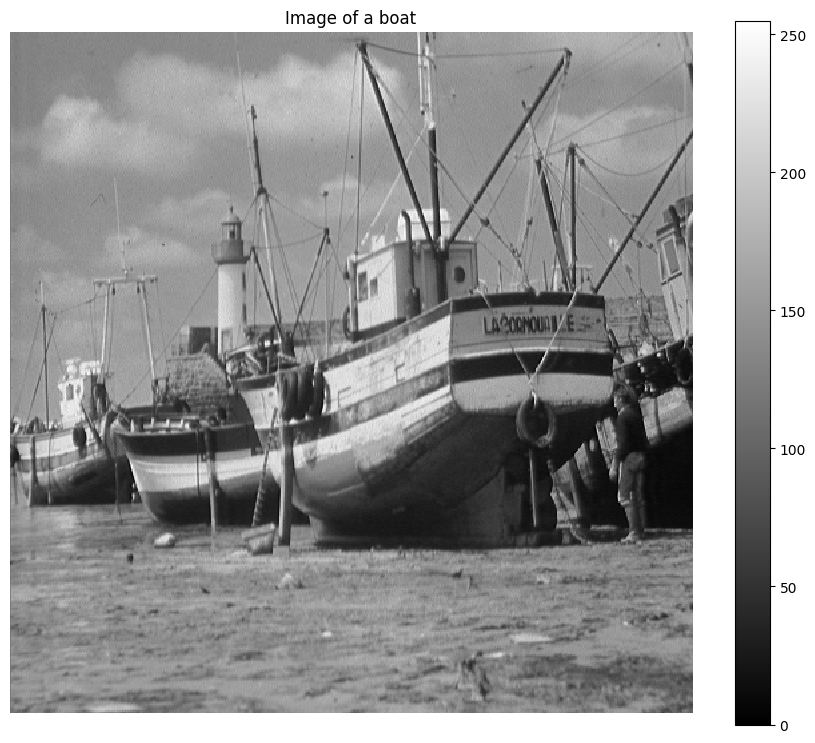

In [4]:
# Display the image
plt.figure(figsize=(11, 11))
plt.imshow(x_bar, interpolation="None", cmap=plt.cm.gray, vmin=0, vmax=255)
# Without specifying vmin and vmax, imshow auto-adjusts its range so that black and white are
# the min and max of the data, respectively.
plt.colorbar()  # displays the color bar close to the image
plt.axis("off")  # remove the axes (comment to restore axes)
plt.subplots_adjust(top=0.75)
plt.title("Image of a boat")
plt.show()

b) We implement the discrete gradient operator $D$ in a Python function

In [5]:
def D(x):
    vdiff = np.r_[
        np.diff(x, 1, 0), np.zeros([1, x.shape[1]])
    ]  # the r_ command concatenates along the rows
    hdiff = np.c_[
        np.diff(x, 1, 1), np.zeros([x.shape[0], 1])
    ]  # the c_ command concatenates along the columns
    return np.concatenate(
        (vdiff[..., np.newaxis], hdiff[..., np.newaxis]), axis=2
    )  # combination along a third dimension
# An alternative, more compact, definition:
# D = lambda x : c_['2,3',r_[np.diff(x,1,0), np.zeros([1,x.shape[1]])],c_[np.diff(x,1,1), np.zeros([x.shape[0],1])]]
## Apply the function to the reference image
v = D(x_bar)

and display the two components of $D\bar{x}$ as two grayscale images.

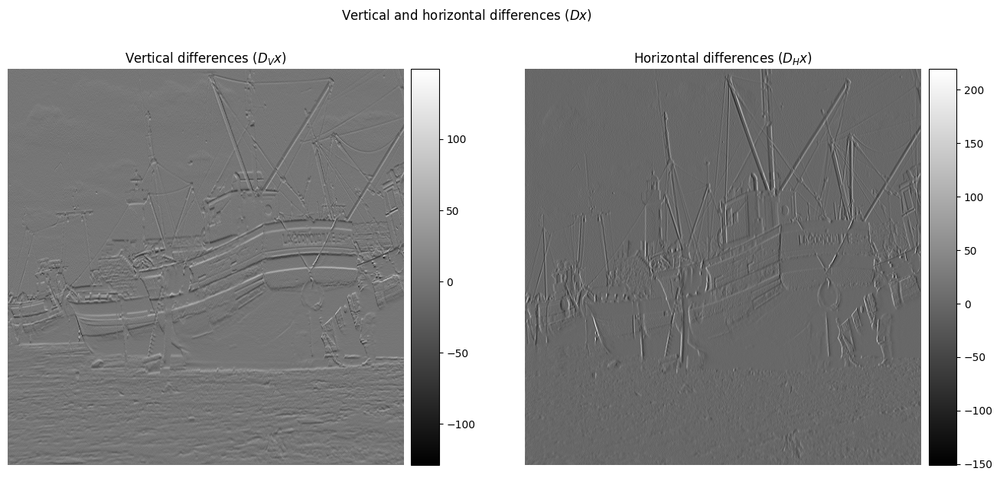

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, (axv, axh) = plt.subplots(
    1, 2, figsize=(16, 7)
)  # one figure with two horizontal subfigures
plt.suptitle(r"Vertical and horizontal differences ($Dx$)")
imv = axv.imshow(v[:, :, 0], cmap=plt.cm.gray)
imh = axh.imshow(v[:, :, 1], cmap=plt.cm.gray)
axv.axis("off")
axh.axis("off")
axv.set_title("Vertical differences ($D_V x$)")
axh.set_title("Horizontal differences ($D_H x$)")
dividerv = make_axes_locatable(axv)
caxv = dividerv.append_axes("right", size="7%", pad=0.1)
plt.colorbar(imv, cax=caxv)
dividerh = make_axes_locatable(axh)
caxh = dividerh.append_axes("right", size="7%", pad=0.1)
plt.colorbar(imh, cax=caxh)
plt.show()

c) Displaying the quantity $\|D\bar{x}\|_F = \sqrt{\|D_V \bar{x}\|_F^2 + \|D_H \bar{x}\|_F^2}$,

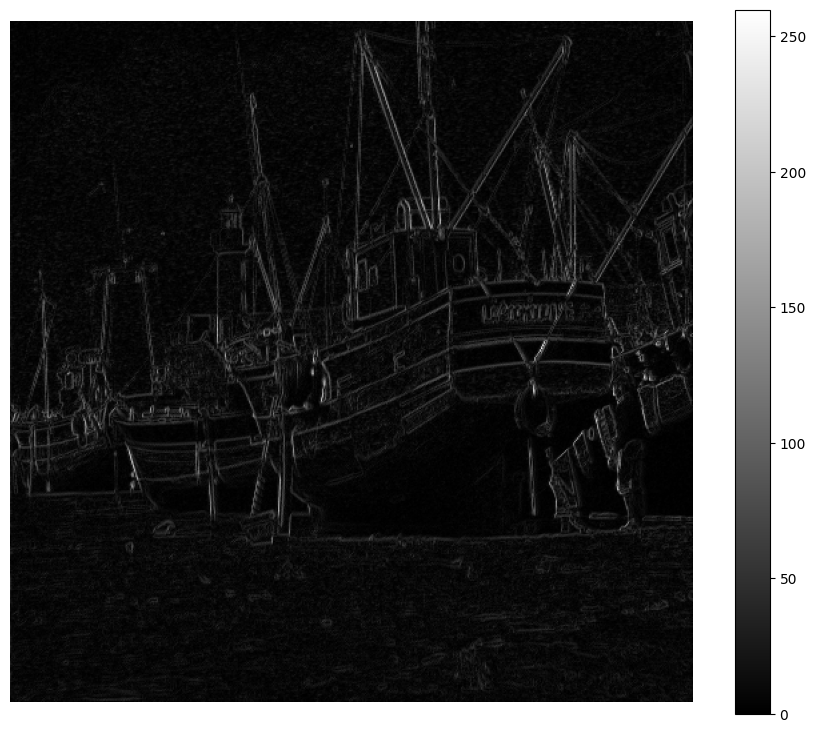

In [7]:
plt.figure(figsize=(11, 11))
plt.imshow(np.sqrt(np.sum(v ** 2, 2)), cmap=plt.cm.gray, vmin=0)
plt.colorbar()
plt.axis("off")
plt.subplots_adjust(top=0.75)

we observe that the energy is concentrated around edges, and relatively low in other pixels. This indicates that the magnitude of the pixels in the discrete gradient appears to be relatively low, except on the edges.

d) Finally, we implement the adjoint of the discrete gradient operator

In [8]:
def D_adj(v):
    return (
        np.r_["0,2", -v[0, :, 0], -np.diff(v[:-1, :, 0], 1, 0), v[-2, :, 0]]
        + np.c_["1,2", -v[:, 0, 1], -np.diff(v[:, :-1, 1], 1, 1), v[:, -2, 1]]
    )

$D^*$ can be viewed as the opposite of a discrete divergence operator. One can check that $\|Dx\|^2 - \langle D^* D x, x \rangle = 0$ to verify that the two operators are adjoint.

In [9]:
(D(x_bar) ** 2).sum() - (D_adj(D(x_bar)) * x_bar).sum()

np.float64(0.0)

## Exercises

### I. A gentle introduction to gradient descent

Consider the minimization of a quadratic form in $\mathbb{R}^2$ ($N = 2$)

$$f(x) = \frac{1}{2}\left(x_1^2 + \eta x_2^2\right)$$

where $\eta > 0$ controls the anisotropy, and hence the difficulty, of the problem.

We first define the anisotropy parameter $\eta$ and the function $f$

In [10]:
eta = 8
f = lambda x: (x[:, 0] ** 2 + eta * x[:, 1] ** 2) / 2

**Note:** a lambda function is a one-line function definition, which captures the value of other variables (in the example above, `eta`).

A simple example:
```python
>> a = 1
>> test_lambda_function = lambda x : x + a
>> #apply the function to the input value 2
>> print(test_lambda_function(2))
3
>> #modify the value of a
>> a = 2
>> #same result as before: a was equal to 1 when the function
>> #was defined
>> print(test_lambda_function(2))
4
```

We display the values taken by the function using a contourplot.

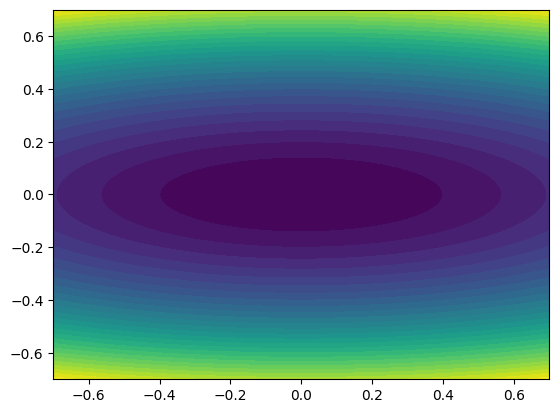

In [11]:
# plt.figsize(6,6)
plt.figure()
t = np.linspace(-0.7, 0.7, 101)
[u, v] = np.meshgrid(t, t)
F = (u ** 2 + eta * v ** 2) / 2
plt.contourf(t, t, F, 35)
plt.show()

We define the gradient of $f$:

In [12]:
grad_f = lambda x: np.array([x[0], eta * x[1]])

Since $f$ is quadratic, its Hessian is the constant matrix $\begin{pmatrix} 1 & 0 \\ 0 & \eta \end{pmatrix}$. Its spectral norm, which is the Lipschitz constant of `grad_f`, is $\beta = \max(1, \eta)$. Since the stepsize $\tau$ must satisfy $0 < \tau < 2/\beta$, we take

In [13]:
tau = 1.8 / max(eta, 1)
tau

0.225

Now we implement the gradient descent method: given the initial estimate $x^{(0)}$ of the solution, the stepsize $\tau$ and the number $k$ of iterations, we compute $x^{(k)}$:

In [14]:
nbiter = 10
x = np.array([1, 1])  # initial estimate of the solution
for iter in range(nbiter):  # iterations from 0 to nbiter-1
    x = x - tau * grad_f(x)
print(x)  # display the value of the solution

[0.07816584 0.10737418]


We encapsulate the above code in a function `gradient_descent`.

In [15]:
def gradient_descent(x0, grad_f, tau, nbiter):
    x = x0
    for iter in range(nbiter):  # iterations from 0 to nbiter-1
        x = x - tau * grad_f(x)
    return x

In [16]:
gradient_descent([1, 1], grad_f, tau, 10)

array([0.07816584, 0.10737418])

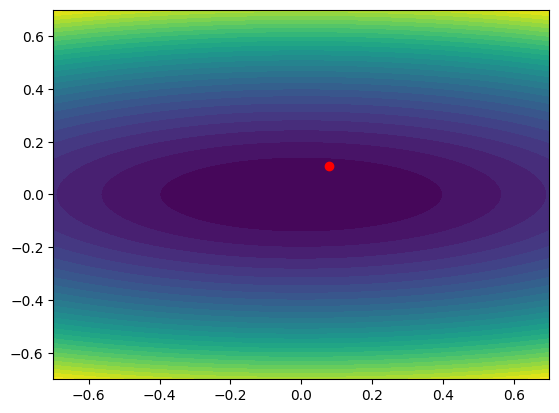

In [17]:
# plt.figsize(6,6)
plt.figure()
t = np.linspace(-0.7, 0.7, 101)
[u, v] = np.meshgrid(t, t)
F = (u ** 2 + eta * v ** 2) / 2
plt.contourf(t, t, F, 35)
plt.plot(0.07816584,0.10737418,'ro')
plt.show()

We modify the previous `gradient_descent` function to store the iterates in a matrix (2-D array).

In [18]:
def gradient_descent(x0, grad_f, tau, nbiter):
    X = np.zeros((nbiter + 1, x0.size))
    X[0, :] = x0
    for iter in range(nbiter):
        X[iter + 1, :] = X[iter, :] - tau * grad_f(X[iter, :])
    return X

In [19]:
X = gradient_descent(np.array([0.6, 0.6]), grad_f, 0.225, 30)

We plot the cost function $f(x^{(k)})$ as a function of $k$, in log-scale:

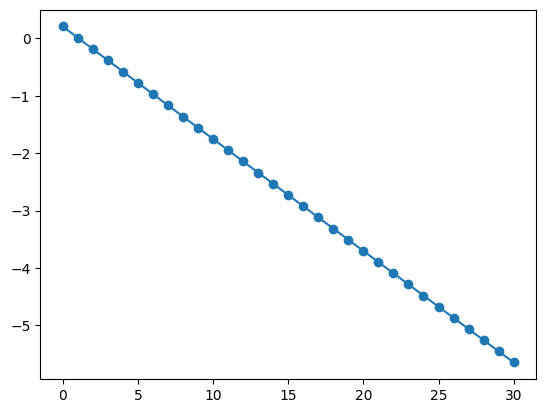

In [20]:
plt.figure()
plt.plot(range(X.shape[0]), np.log10(f(X)), "o-")
plt.show()

Observe that the gradient descent algorithm is monotonic, in that $f(x^{(k)})$ decreases from one iteration to another.

We plot the iterates above the contourplot of $f$:

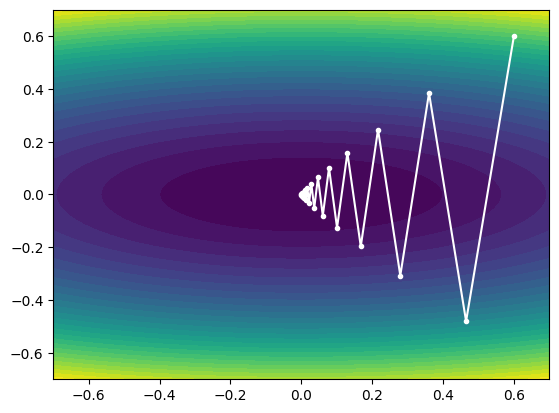

In [21]:
# figsize(8,8)
plt.figure()
plt.contourf(t, t, F, 35)
plt.plot(X[:, 0], X[:, 1], "w.-")
plt.show()

### Questions:

1. Adapt the previous cells to run the algorithm with different values of tau (try 0.25, 0.225, 0.2, 0.05). Qualitatively, is the algorithm converging for each of these values? For which value does it converge the fastest to the solution?
2. Try a different initial estimate (e.g., a randomly generated one). Does the algorithm still converge to the solution of the problem? Justify your statement with a theoretical argument from the lectures.

### Answers to the questions of Exercise I

**Question 1.** Trajectories and cost $f(x^{(k)})$ over 50 iterations from $x^{(0)} = (0.6, 0.6)$, for each stepsize. Since $\nabla f(x) = (x_1, \eta x_2)$, each iteration multiplies the coordinates by $1 - \tau$ and $1 - \tau\eta$ respectively.

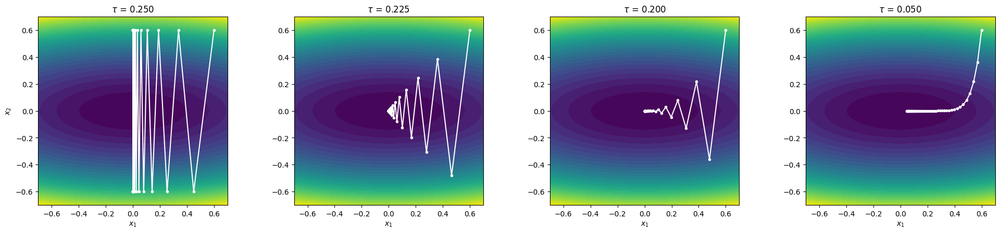

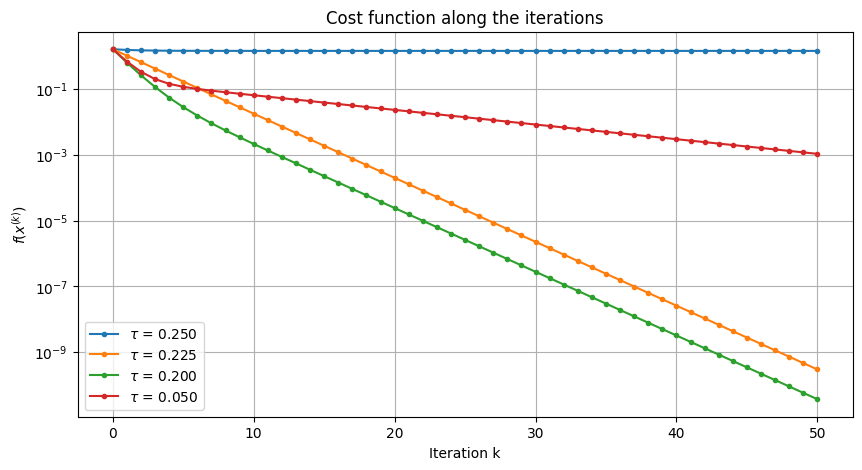

Contraction factors |1 - tau| and |1 - tau*eta| per iteration:
  tau = 0.2500                    : 0.750 and 1.000 -> rate 1.000, f(x_50) = 1.44e+00
  tau = 0.2250                    : 0.775 and 0.800 -> rate 0.800, f(x_50) = 2.95e-10
  tau = 0.2000                    : 0.800 and 0.600 -> rate 0.800, f(x_50) = 3.67e-11
  tau = 0.0500                    : 0.950 and 0.600 -> rate 0.950, f(x_50) = 1.07e-03
  tau = 0.2222 (optimal 2/(1+eta)): 0.778 and 0.778 -> rate 0.778


In [22]:
x0 = np.array([0.6, 0.6])
taus = [0.25, 0.225, 0.2, 0.05]
nbiter = 50

fig, axes = plt.subplots(1, len(taus), figsize=(20, 4.5))
costs = {}
for ax, tau in zip(axes, taus):
    X = gradient_descent(x0, grad_f, tau, nbiter)
    costs[tau] = f(X)
    ax.contourf(t, t, F, 35)
    ax.plot(X[:, 0], X[:, 1], "w.-")
    ax.set_title(r"$\tau$ = %.3f" % tau)
    ax.set_xlabel("$x_1$")
    ax.set_aspect("equal")
axes[0].set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for tau in taus:
    plt.semilogy(costs[tau], ".-", label=r"$\tau$ = %.3f" % tau)
plt.xlabel("Iteration k")
plt.ylabel("$f(x^{(k)})$")
plt.title("Cost function along the iterations")
plt.legend()
plt.grid()
plt.show()

tau_opt = 2 / (1 + eta)
print("Contraction factors |1 - tau| and |1 - tau*eta| per iteration:")
for tau in taus + [tau_opt]:
    r1, r2 = abs(1 - tau), abs(1 - tau * eta)
    label = "tau = %.4f" % tau + (" (optimal 2/(1+eta))" if tau == tau_opt else "")
    print("  %-32s: %.3f and %.3f -> rate %.3f%s" % (label, r1, r2, max(r1, r2),
          "" if tau == tau_opt else ", f(x_50) = %.2e" % costs[tau][-1]))

**Analysis.** Since $\nabla f(x) = (x_1, \eta x_2)$, one iteration reads $x_1^{(k+1)} = (1 - \tau)\, x_1^{(k)}$ and $x_2^{(k+1)} = (1 - \tau\eta)\, x_2^{(k)}$: each coordinate is multiplied by a constant factor, and the iterates converge to the minimiser $x^\star = 0$ if and only if both factors have a modulus smaller than 1, i.e. $0 < \tau < 2/\eta = 2/\beta$ = 0.25. The asymptotic convergence rate is $\rho(\tau) = \max(|1 - \tau|, |1 - \tau\eta|)$.

- **$\tau$ = 0.25 = $2/\beta$: no convergence.** The factor along $x_2$ is $1 - 0.25 \times 8 = -1$: $x_2$ jumps forever between +0.6 and -0.6 (vertical zigzag), and $f(x^{(k)})$ stays around 1.44. Only $x_1$ converges. The bound $\tau < 2/\beta$ is strict.
- **$\tau$ = 0.225 and $\tau$ = 0.2: fast convergence**, with the same rate $\rho$ = 0.8. With 0.225 the factor along $x_2$ is -0.8, hence the zigzag across the valley that slowly shrinks; with 0.2 it is -0.6, so the oscillation dies faster and the trajectory quickly reaches the $x_1$ axis, then goes straight to the minimum. After 50 iterations, $f$ = $3.7 \times 10^{-11}$ for $\tau$ = 0.2 and $3.0 \times 10^{-10}$ for $\tau$ = 0.225: **$\tau$ = 0.2 is the fastest** of the four values, very slightly.
- **$\tau$ = 0.05: slow convergence**, without oscillation. The factor along $x_2$ (0.6) is fine, but along $x_1$ it is 0.95, so the iterates first go down to the axis $x_2 = 0$ and then crawl along the flat direction of the valley; $f$ is still $10^{-3}$ after 50 iterations.

The best possible stepsize balances the two factors, $1 - \tau = -(1 - \tau\eta)$, i.e. $\tau^\star = 2/(1 + \eta) \approx 0.222$, with the rate $(\eta - 1)/(\eta + 1) \approx 0.778$: the larger the anisotropy $\eta$ (the condition number of the Hessian), the slower the gradient descent. A stepsize close to (but below) $2/\beta$ is not the best choice either: at $2/\beta$ the method does not converge at all.

**Question 2.** 20 random initial points drawn uniformly in $[-0.7, 0.7]^2$, with $\tau$ = 0.225.

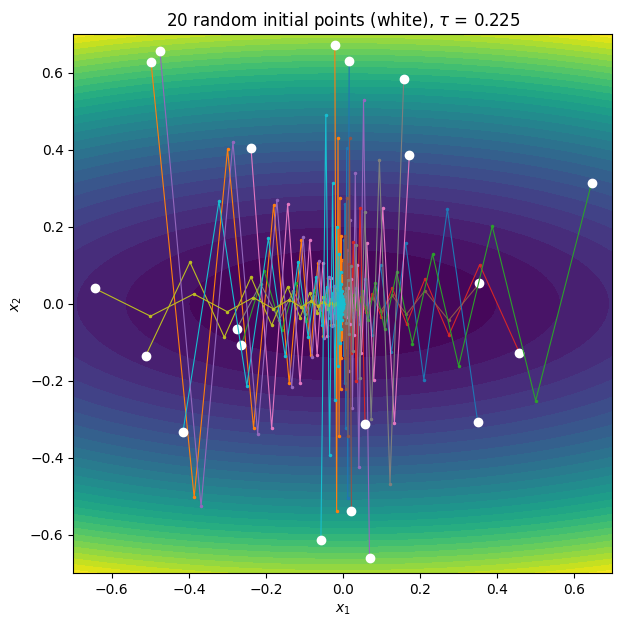

Largest distance to the minimiser after 50 iterations: 9.6e-06


In [23]:
rng = np.random.default_rng(1)
tau = 0.225
plt.figure(figsize=(7, 7))
plt.contourf(t, t, F, 35)
final_norms = []
for _ in range(20):
    x0 = rng.uniform(-0.7, 0.7, size=2)
    X = gradient_descent(x0, grad_f, tau, 50)
    final_norms.append(np.linalg.norm(X[-1]))
    plt.plot(X[:, 0], X[:, 1], ".-", linewidth=0.8, markersize=3)
    plt.plot(x0[0], x0[1], "wo")
plt.gca().set_aspect("equal")
plt.title(r"20 random initial points (white), $\tau$ = 0.225")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()
print("Largest distance to the minimiser after 50 iterations: %.1e" % max(final_norms))

**Yes, the algorithm converges to $x^\star = 0$ from any initial point**: for the 20 random initial points, the distance to the minimiser after 50 iterations is below $10^{-5}$. All the trajectories have the same behaviour: a zigzag along $x_2$ that shrinks, and a monotonic decrease along $x_1$.

**Theoretical argument.** $f$ is convex and differentiable, and its gradient is $\beta$-Lipschitz with $\beta = \max(1, \eta) = 8$. The convergence theorem of the gradient method (see the Theory section) states that for any stepsize $0 < \tau < 2/\beta$ the sequence $(x^{(k)})$ converges to a minimiser of $f$, **whatever the initial point** $x^{(0)}$; here $\tau$ = 0.225 < 0.25. Moreover $f$ is strongly convex (the Hessian $\mathrm{diag}(1, \eta)$ has eigenvalues $\geq 1$), so its minimiser is unique and the convergence is linear: $\|x^{(k)} - x^\star\| \leq \rho^k \|x^{(0)} - x^\star\|$ with $\rho = \max(|1 - \tau|, |1 - \tau\eta|) = 0.8$. This can be checked directly on this example since $x^{(k)} = \mathrm{diag}\big((1 - \tau)^k, (1 - \tau\eta)^k\big)\, x^{(0)}$ for every $x^{(0)}$. The initial point only changes the constant, not the convergence: for instance, starting on an axis ($x^{(0)} = (0, 0.7)$) gives a pure vertical zigzag.

---

### II. Image denoising with the gradient descent

Denoising an image $y \in \mathbb{R}^{N_1 \times N_2}$ can be seen as a special instance of the problem described in the theory paragraph above with $A = I$, the identity operator. Assuming the noise corrupting the data is white and Gaussian, of variance $\sigma^2$, denoising can be formulated as

$$\min_{x \in \mathbb{R}^N} \frac{1}{2}\|x - y\|_F^2 + \frac{\lambda}{2}\|Dx\|_F^2.$$

> Note that $x$ belongs to a Euclidean space of dimension $N = N_1 N_2$, which is the number of pixels composing the image.

For numerical applications, we will consider $\lambda = 8$.

**Generating synthetic data**

1. **[Python]** Load a ground truth image with Python, stored in a variable `x_bar` (you can use the sample code given in the Theory section).

(512, 512)
Image size: 512 x 512.
Pixel values are in the interval [0,255].


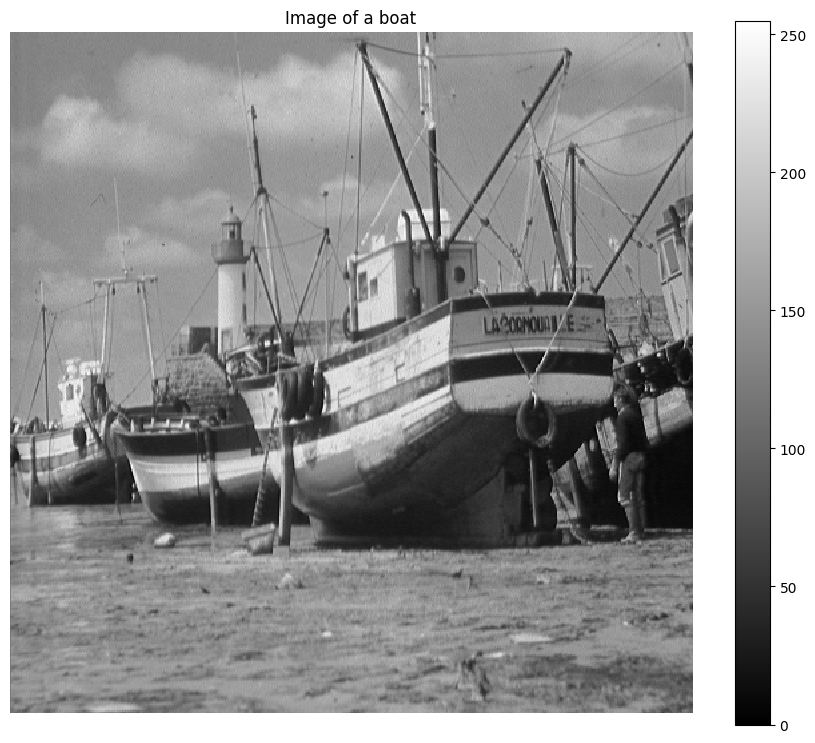

In [24]:
# Load the image
imgpil = Image.open("img/boat.png")
x_bar = np.array(imgpil)
imgpil.close()
print(x_bar.shape)
print("Image size: %s x %s." % (x_bar.shape[0], x_bar.shape[1]))
print("Pixel values are in the interval [%s,%s]." % (x_bar.min(), x_bar.max()))
x_bar = x_bar.astype(float)  # ensure pixel values are floating point numbers
# Display the image
plt.figure(figsize=(11, 11))
plt.imshow(x_bar, interpolation="None", cmap=plt.cm.gray, vmin=0, vmax=255)
# Without specifying vmin and vmax, imshow auto-adjusts its range so that black and white are
# the min and max of the data, respectively.
plt.colorbar()  # displays the color bar close to the image
plt.axis("off")  # remove the axes (comment to restore axes)
plt.subplots_adjust(top=0.75)
plt.title("Image of a boat")
plt.show()

2. **[Theory/Python]** The input signal-to-noise ratio (iSNR) is defined as

$$\text{iSNR} = 10\log_{10}\left(\frac{\|y_0\|_F^2}{N\sigma^2}\right) \tag{6}$$

where $y_0 \in \mathbb{R}^{N_1 \times N_2}$ denotes the noiseless data (i.e., $y_0 = \bar{x}$ for the denoising problem), and $\sigma^2$ is the variance of the white Gaussian noise.

a) Give the expression of $\sigma^2$ in function of the iSNR. Complete the code cell below to compute its value for iSNR = 20 dB, and generate the noisy data using the measurement model

$$y = \bar{x} + n = y_0 + n \tag{7}$$

with $n$ a realization of the random vector $n \sim \mathcal{N}(0, \sigma^2 I)$.

> **Hint:**
> - generating random variables: as an example, independent, identically distributed uniform random variables can be generated with the following piece of code
> ```python
> rng = np.random.default_rng(0) # set random seed
> rv = rng.uniform(2,2) # generate i.i.d uniform random variables
> ```
> - to generate a Gaussian random variable, take a look at the documentation of the numpy function `numpy.random.normal`
> - to compute the norm of a vector, take a look at the documentation of the numpy function `numpy.linalg.norm`

**Your answers**

**a)** From the definition of the iSNR,
$$\text{iSNR} = 10\log_{10}\left(\frac{\|y_0\|_F^2}{N\sigma^2}\right) \iff \frac{\|y_0\|_F^2}{N\sigma^2} = 10^{\text{iSNR}/10} \iff \boxed{\sigma^2 = \frac{\|y_0\|_F^2}{N\, 10^{\text{iSNR}/10}}}$$

For iSNR = 20 dB, the noise power is 100 times smaller than the mean power of the image. Note that `rng.normal(loc, scale, size)` expects the **standard deviation** `scale` $= \sigma = \sqrt{\sigma^2}$, not the variance.

In [25]:
(N1, N2) = x_bar.shape
N = N1 * N2
isnr = 20  # input SNR (in dB)
sigma2 = np.linalg.norm(x_bar, ord="fro") ** 2 / (N * 10 ** (isnr / 10))  # noise variance
sigma = np.sqrt(sigma2)  # standard deviation, expected by rng.normal

rng = np.random.default_rng(0)  # fixed seed: reproducible results
n = rng.normal(0.0, sigma, x_bar.shape)
y = x_bar + n

print("sigma^2 = %.2f, sigma = %.2f (grey levels)" % (sigma2, sigma))
print("Empirical input SNR: %.2f dB" % (10 * np.log10(np.linalg.norm(x_bar) ** 2 / np.linalg.norm(n) ** 2)))

sigma^2 = 190.03, sigma = 13.79 (grey levels)
Empirical input SNR: 19.99 dB


b) Display the noisy image and the ground truth (with a gray colorbar).

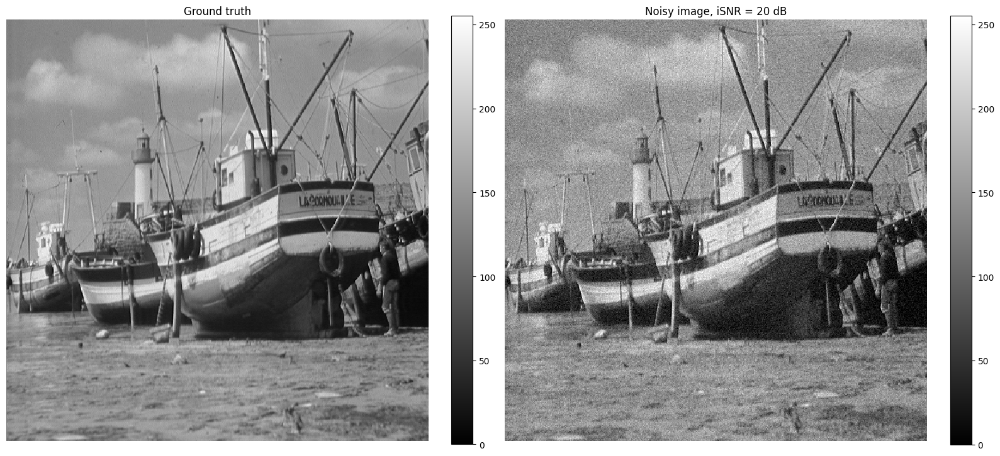

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, img, ttl in [(axes[0], x_bar, "Ground truth"), (axes[1], y, "Noisy image, iSNR = 20 dB")]:
    im = ax.imshow(img, interpolation="None", cmap=plt.cm.gray, vmin=0, vmax=255)
    ax.set_title(ttl)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

**Gradient descent algorithm**

3. **[Theory/Python]**: Give the expression of $\nabla f$ for this denoising problem. Implement a Python function `grad_f` to compute its value, using the discrete gradient `D` and its adjoint `D_adj`.

```python
def grad_f(x, y, Lambda):
    # return ?
```

**Your answers**

With $f(x) = \frac{1}{2}\|Ax - y\|_F^2 + \frac{\lambda}{2}\|Dx\|_F^2$, we have $\nabla f(x) = A^*(Ax - y) + \lambda D^* D x$. For denoising, $A = I$ (identity operator on $\mathbb{R}^{N_1 \times N_2}$), hence

$$\nabla f(x) = (x - y) + \lambda D^* D x = (I + \lambda D^* D)\, x - y.$$

The minimiser is the solution of the linear system $(I + \lambda D^* D)\, x = y$. The function below implements $\nabla f$ with `D` and `D_adj`, and the finite-difference test confirms the expression.

In [27]:
def grad_f(x, y, Lambda):
    # gradient of f(x) = 1/2 ||x - y||_F^2 + Lambda/2 ||D x||_F^2
    return (x - y) + Lambda * D_adj(D(x))


def cost_denoising(x, y, Lambda):
    return 0.5 * np.sum((x - y) ** 2) + 0.5 * Lambda * np.sum(D(x) ** 2)


# numerical check of the gradient with a finite difference in a random direction
rng_check = np.random.default_rng(3)
x_test, d_test = rng_check.normal(size=(2, 64, 64))
y_test = rng_check.normal(size=(64, 64))
eps = 1e-6
fd = (cost_denoising(x_test + eps * d_test, y_test, 8) - cost_denoising(x_test - eps * d_test, y_test, 8)) / (2 * eps)
print("Directional derivative: finite difference %.6f, <grad_f, d> = %.6f"
      % (fd, np.sum(grad_f(x_test, y_test, 8) * d_test)))

Directional derivative: finite difference -1399.133500, <grad_f, d> = -1399.133500


4. **[Python]**: The expression of the Lipschitz constant $\beta$ can be taken as $\|I + \lambda D^* D\| = 1 + 8\lambda$. Using this information and the function `grad_f` implemented in 3., apply the gradient descent algorithm ($\approx 100$ iterations) to estimate a solution to the denoising problem. Make sure the function returns both the final estimate and the values $(f(x^{(k)}))_k$.

> **Hint:** use the example gradient descent introduced in the first exercise.

beta = 65, tau = 0.0292
Largest eigenvalue of I + Lambda D*D: 65.00 (bound used: 65)
f(x_100) - f(x*) = 1.391e+03, relative: 1.86e-05
Relative distance ||x_100 - x*|| / ||x*|| = 6.84e-04


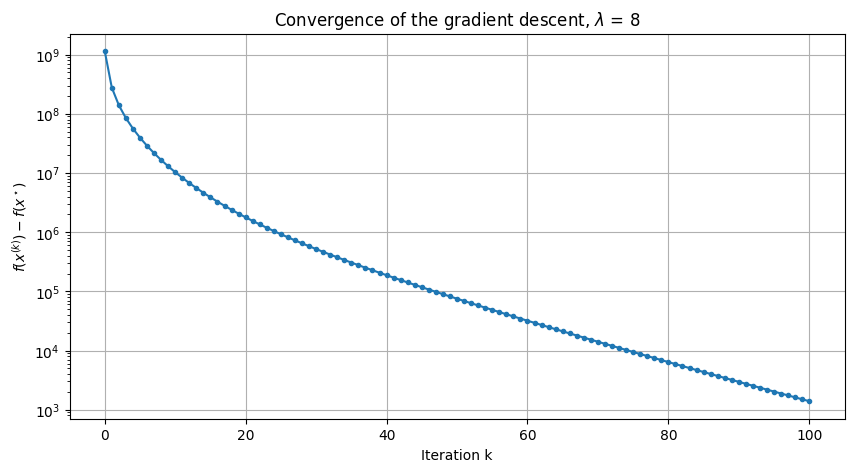

In [28]:
def gradient_descent(grad_f, y, Lambda, x0, nbiter, tau):
    # gradient descent for the denoising problem
    # returns the final estimate and the values (f(x^(k)))_k, k = 0..nbiter
    x = x0.copy()
    costs = [cost_denoising(x, y, Lambda)]
    for _ in range(nbiter):
        x = x - tau * grad_f(x, y, Lambda)
        costs.append(cost_denoising(x, y, Lambda))
    return x, np.array(costs)


Lambda = 8
beta = 1 + 8 * Lambda  # Lipschitz constant of grad_f
tau = 1.9 / beta
nbiter = 100
x_den, costs = gradient_descent(grad_f, y, Lambda, y, nbiter, tau)
print("beta = %d, tau = %.4f" % (beta, tau))

# exact minimiser: I + Lambda D*D is diagonalised by the 2D DCT (Neumann boundary conditions)
from scipy.fft import dctn, idctn
p = np.arange(N1)[:, None]
q = np.arange(N2)[None, :]
eig_DtD = 4 * np.sin(np.pi * p / (2 * N1)) ** 2 + 4 * np.sin(np.pi * q / (2 * N2)) ** 2
x_star = idctn(dctn(y, norm="ortho") / (1 + Lambda * eig_DtD), norm="ortho")
f_star = cost_denoising(x_star, y, Lambda)
print("Largest eigenvalue of I + Lambda D*D: %.2f (bound used: %d)" % (1 + Lambda * eig_DtD.max(), beta))
print("f(x_100) - f(x*) = %.3e, relative: %.2e" % (costs[-1] - f_star, (costs[-1] - f_star) / f_star))
print("Relative distance ||x_100 - x*|| / ||x*|| = %.2e" % (np.linalg.norm(x_den - x_star) / np.linalg.norm(x_star)))

plt.figure(figsize=(10, 5))
plt.semilogy(costs - f_star, ".-")
plt.xlabel("Iteration k")
plt.ylabel(r"$f(x^{(k)}) - f(x^\star)$")
plt.title(r"Convergence of the gradient descent, $\lambda$ = 8")
plt.grid()
plt.show()

The gradient descent is run from $x^{(0)} = y$ with $\tau = 1.9/\beta$ and $\beta = 1 + 8\lambda = 65$, which is exactly the largest eigenvalue of $I + \lambda D^* D$ (the eigenvalues of $D^* D$ with Neumann boundary conditions are $4\sin^2(\pi p/2N_1) + 4\sin^2(\pi q/2N_2) \leq 8$).

To check the result, the exact minimiser $x^\star$ is also computed: $I + \lambda D^* D$ is diagonal in the basis of the 2D discrete cosine transform, so $x^\star$ is obtained by dividing the DCT coefficients of $y$ by $1 + \lambda\,\mu_{p,q}$. After 100 iterations, $f(x^{(100)})$ is within $2 \times 10^{-5}$ (relative) of $f(x^\star)$, and $\|x^{(100)} - x^\star\| / \|x^\star\| = 7 \times 10^{-4}$: the algorithm has practically converged. The cost decreases monotonically, fast at the beginning (high frequencies of the noise, which correspond to large eigenvalues) and more slowly afterwards (the rate is limited by the ratio between the largest and the smallest eigenvalues of $I + \lambda D^* D$, i.e. 65).

**Interpretation of the results**

5. **[Theory/Python]**: Display the denoised and the ground truth image. What do you observe? Are details well recovered? Conclude about the relevance of Tikhonov regularization for denoising natural images.

PSNR noisy: 25.33 dB, denoised (lambda = 8): 24.09 dB


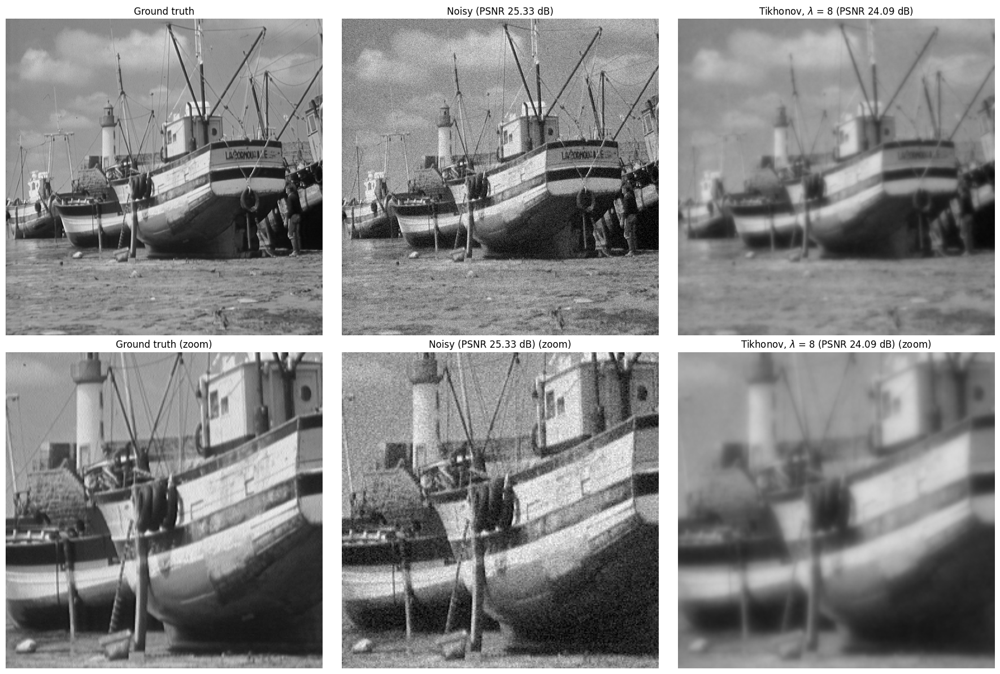

lambda =  0.25: PSNR = 29.24 dB
lambda =  0.50: PSNR = 29.51 dB
lambda =  1.00: PSNR = 28.57 dB
lambda =  2.00: PSNR = 27.02 dB
lambda =  4.00: PSNR = 25.46 dB
lambda =  8.00: PSNR = 24.07 dB
lambda = 16.00: PSNR = 22.86 dB
lambda = 32.00: PSNR = 21.77 dB


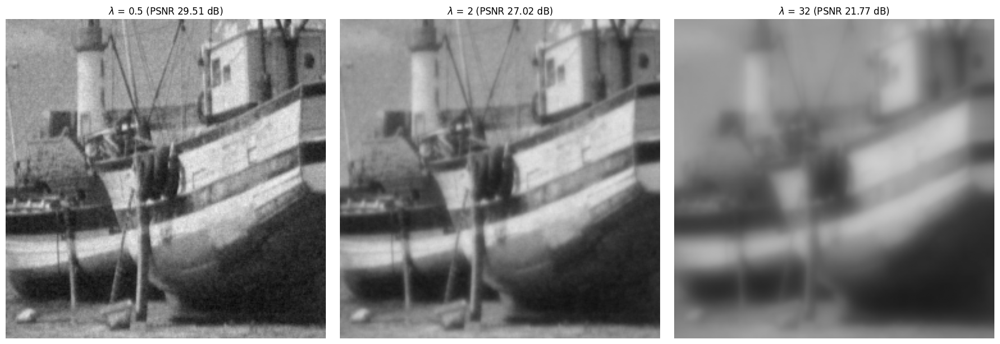

In [29]:
def psnr(ref, img, vmax=255.0):
    return 10 * np.log10(vmax ** 2 / np.mean((ref - img) ** 2))


print("PSNR noisy: %.2f dB, denoised (lambda = 8): %.2f dB" % (psnr(x_bar, y), psnr(x_bar, x_den)))

zoom = (slice(150, 400), slice(100, 350))
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for c, (img, ttl) in enumerate([(x_bar, "Ground truth"), (y, "Noisy (PSNR %.2f dB)" % psnr(x_bar, y)),
                                (x_den, r"Tikhonov, $\lambda$ = 8 (PSNR %.2f dB)" % psnr(x_bar, x_den))]):
    axes[0, c].imshow(img, cmap=plt.cm.gray, vmin=0, vmax=255)
    axes[0, c].set_title(ttl)
    axes[1, c].imshow(img[zoom], cmap=plt.cm.gray, vmin=0, vmax=255)
    axes[1, c].set_title(ttl + " (zoom)")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

# influence of lambda (exact minimisers computed with the DCT)
lambdas = [0.25, 0.5, 1, 2, 4, 8, 16, 32]
psnrs = [psnr(x_bar, idctn(dctn(y, norm="ortho") / (1 + lam * eig_DtD), norm="ortho")) for lam in lambdas]
for lam, val in zip(lambdas, psnrs):
    print("lambda = %5.2f: PSNR = %.2f dB" % (lam, val))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, lam in zip(axes, [0.5, 2, 32]):
    img = idctn(dctn(y, norm="ortho") / (1 + lam * eig_DtD), norm="ortho")
    ax.imshow(img[zoom], cmap=plt.cm.gray, vmin=0, vmax=255)
    ax.set_title(r"$\lambda$ = %g (PSNR %.2f dB)" % (lam, psnr(x_bar, img)))
    ax.axis("off")
plt.tight_layout()
plt.show()

**Observations.** With $\lambda$ = 8, the noise has disappeared, but the image is **strongly blurred**: the ropes and thin masts are almost invisible, the name of the boat can no longer be read, and all the edges are smooth transitions. Details are **not** well recovered. In fact, the PSNR of the denoised image (24.1 dB) is even **lower than that of the noisy image** (25.3 dB): with this value of $\lambda$, the error introduced by the blur is larger than the noise that has been removed.

**Influence of $\lambda$.** The exact solutions for several $\lambda$ show the compromise: small $\lambda$ keeps the details but also the noise, large $\lambda$ removes the noise but destroys the details. The best PSNR is obtained for **$\lambda \approx$ 0.5 (29.5 dB, +4.2 dB)**; for this value some noise remains visible in flat areas, while edges are already slightly blurred. There is no value of $\lambda$ that removes the noise without blurring the edges.

**Relevance of Tikhonov regularisation.** The quadratic penalty $\|Dx\|_F^2$ encodes the prior that natural images vary smoothly, which is true inside regions but false at edges. Being quadratic, it penalises strongly the large differences between neighbouring pixels, i.e. precisely the edges, which are smoothed as much as the noise. Equivalently, the solution is a linear low-pass filter, $x^\star = (I + \lambda D^* D)^{-1} y$, with frequency response $1/(1 + \lambda\mu_{p,q})$: noise and details occupy the same high frequencies and are attenuated in the same way. Tikhonov regularisation is simple and fast (one linear system), but it is **poorly suited to natural images**. Priors that tolerate a few large gradients, such as total variation $\|Dx\|_{1}$ or sparsity in a wavelet basis (lab 2), preserve edges much better; they lead to non-smooth problems solved with the proximal algorithms of the lecture.

---

### III. Image inpainting with the projected gradient descent

Inpainting consists in inferring the value of missing pixels in an image from a set of available pixels. In this section, we will recover the content of an image knowing the value of only 10% of its pixels.

We first formulate inpainting as the following optimization problem

$$\min_{x \in \Omega} f(x) \quad \equiv \quad \min_{x \in \mathbb{R}^{N_1 \times N_2}} \frac{1}{2}\|Dx\|_F^2 \quad \text{s.t.} \quad Ax = y.$$

**Synthetic data generation**

In [30]:
# Load the image
imgpil = Image.open("img/boat.png")
x_bar = np.array(imgpil)
imgpil.close()
print(x_bar.shape)
print("Image size: %s x %s." % (x_bar.shape[0], x_bar.shape[1]))
print("Pixel values are in the interval [%s,%s]." % (x_bar.min(), x_bar.max()))
x_bar = x_bar.astype(float)  # ensure pixel values are floating point numbers

(512, 512)
Image size: 512 x 512.
Pixel values are in the interval [0,255].


6. **[Python]**: The degradation operator $A$ is simply pixelwise multiplication by the binary mask, and we have $A^* = A$.

Generate a random mask to select 10% of the ground truth image $\bar{x}$ to simulate a partially observed image. Generate the image to be inpainted $y$. Display the mask and the data $y$.

> **Hint:** you can for instance use the `np.random.rand` function to generate the mask (of the same size as the image). Another option consists in using `np.random.choice` and `np.unravel_index`.

Proportion of observed pixels: 10.07 %


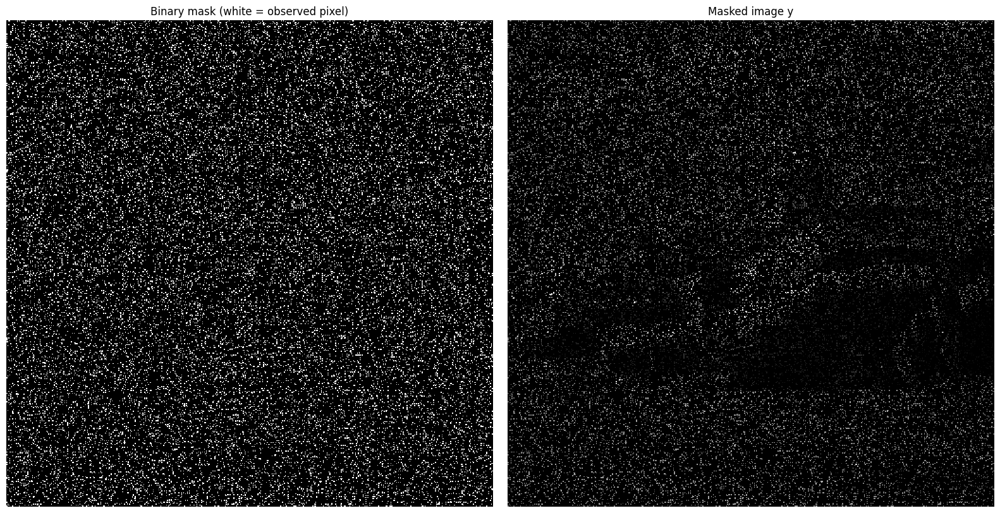

In [31]:
rng = np.random.default_rng(0)  # fixed seed: reproducible results
mask = (rng.random(x_bar.shape) < 0.1).astype(float)  # 1 = observed pixel (10 %), 0 = missing pixel
print("Proportion of observed pixels: %.2f %%" % (100 * mask.mean()))


def A_op(x):
    # degradation operator: pixelwise multiplication by the mask (A* = A)
    return mask * x


y = A_op(x_bar)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(mask, interpolation="None", cmap=plt.cm.gray)
axes[0].set_title("Binary mask (white = observed pixel)")
axes[1].imshow(y, interpolation="None", cmap=plt.cm.gray, vmin=0, vmax=255)
axes[1].set_title("Masked image y")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Projected gradient descent**

7. **[Python]** Implement a function `grad_f` to compute $\nabla f$.

**Your answer**

With $f(x) = \frac{1}{2}\|Dx\|_F^2 = \frac{1}{2}\langle Dx, Dx\rangle$, the gradient is $\nabla f(x) = D^* D x$ (same computation as in question 3 with $A = 0$). Its Lipschitz constant is $\|D^* D\| = 8$.

In [32]:
def grad_f(x):
    # gradient of f(x) = 1/2 ||D x||_F^2
    return D_adj(D(x))

8. **[Python]** Implement a function `projection_inpainting` to compute the projection of a vector $u$ onto the closed convex set $\{x \mid Ax = y\}$.

> **Hint:** projecting onto this set reduces to setting $u_i = y_i$ for the indices $i$ which are not masked.

**Your answer**

The set $\Omega = \{x \mid Ax = y\}$ contains the images that coincide with $y$ on the observed pixels, without any constraint on the missing ones. The projection of $u$ minimises $\|x - u\|_F^2 = \sum_i (x_i - u_i)^2$ under this constraint: the missing pixels are free, so the best choice is $x_i = u_i$, and the observed pixels are imposed, $x_i = y_i$. The implementation is a vectorised `np.where`, which is several hundred times faster than a double loop over the pixels (an important point, since the projection is applied at each iteration).

In [33]:
def projection_inpainting(u, y, mask):
    # orthogonal projection onto {x | A x = y}: observed pixels are replaced by their value in y
    return np.where(mask == 1, y, u)

9. **[Python]** Knowing that $\beta = 8$, implement a projected gradient algorithm to solve the inpainting problem.

```python
def projected_gradient_descent(grad_f, projection_inpainting, y, mask, x0, nbiter, tau):
    ...
```

In [34]:
def projected_gradient_descent(grad_f, projection_inpainting, y, mask, x0, nbiter, tau, snapshots=()):
    # projected gradient descent for the inpainting problem
    # returns the final estimate, the values f(x^(k)) and a dictionary of intermediate images
    x = projection_inpainting(x0, y, mask)
    costs = [0.5 * np.sum(D(x) ** 2)]
    saved = {0: x.copy()} if 0 in snapshots else {}
    for k in range(1, nbiter + 1):
        x = projection_inpainting(x - tau * grad_f(x), y, mask)
        costs.append(0.5 * np.sum(D(x) ** 2))
        if k in snapshots:
            saved[k] = x.copy()
    return x, np.array(costs), saved

**Interpretation of the results**

10. **[Theory/Python]** Apply the projected gradient algorithm starting from $x^{(0)} = y$, for 300 iterations. Display the estimated image, and conclude about the efficiency of this approach.

### Answers to question 10

   3 iterations: PSNR = 7.73 dB
  30 iterations: PSNR = 17.87 dB
 300 iterations: PSNR = 24.41 dB
1000 iterations: PSNR = 24.41 dB
5000 iterations: PSNR = 24.41 dB
Change between 1000 and 5000 iterations: 0.00 grey levels (RMS)


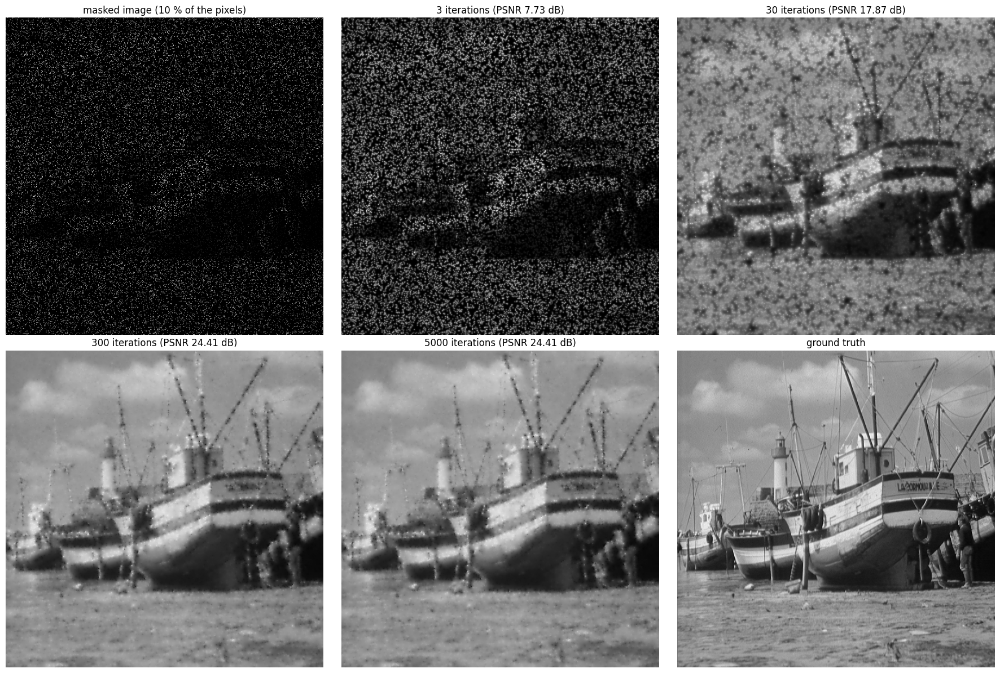

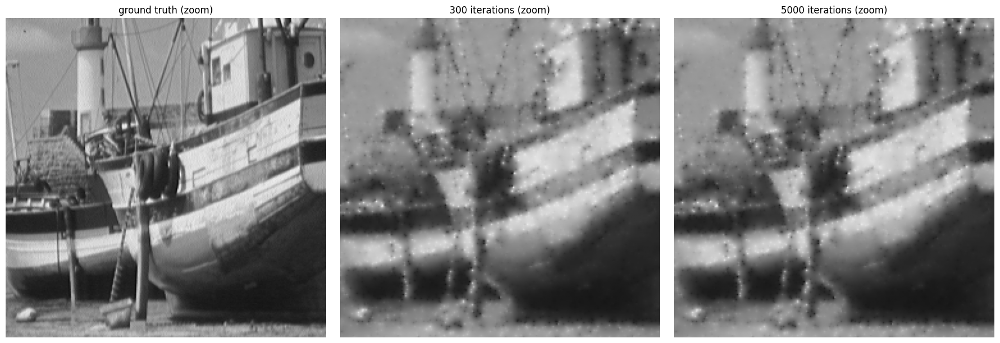

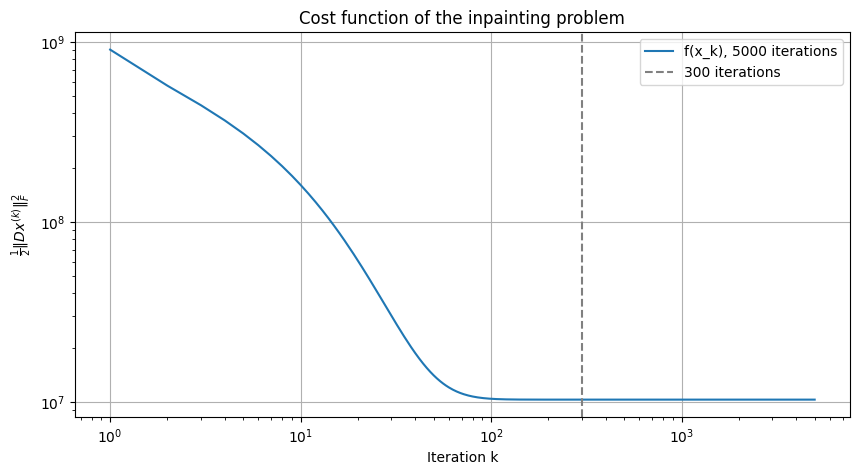

In [35]:
beta = 8
tau = 1.9 / beta
nbiter = 300
x0 = y
xrestored, costs_inp, saved = projected_gradient_descent(grad_f, projection_inpainting, y, mask, x0, nbiter, tau,
                                                         snapshots=(3, 30, 300))

# much longer run, to see how far 300 iterations are from convergence
x_long, costs_long, saved_long = projected_gradient_descent(grad_f, projection_inpainting, y, mask, x0, 5000, tau,
                                                            snapshots=(1000, 5000))

for k, img in [(3, saved[3]), (30, saved[30]), (300, xrestored), (1000, saved_long[1000]), (5000, x_long)]:
    print("%4d iterations: PSNR = %.2f dB" % (k, psnr(x_bar, img)))
print("Change between 1000 and 5000 iterations: %.2f grey levels (RMS)" % np.sqrt(np.mean((saved_long[1000] - x_long) ** 2)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (img, ttl) in zip(axes.ravel(), [(y, "masked image (10 % of the pixels)"),
                                         (saved[3], "3 iterations"), (saved[30], "30 iterations"),
                                         (xrestored, "300 iterations"), (x_long, "5000 iterations"),
                                         (x_bar, "ground truth")]):
    ax.imshow(img, cmap=plt.cm.gray, vmin=0, vmax=255)
    ax.set_title(ttl + ("" if img is y or img is x_bar else " (PSNR %.2f dB)" % psnr(x_bar, img)))
    ax.axis("off")
plt.tight_layout()
plt.show()

zoom = (slice(150, 400), slice(100, 350))
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (img, ttl) in zip(axes, [(x_bar, "ground truth"), (xrestored, "300 iterations"), (x_long, "5000 iterations")]):
    ax.imshow(img[zoom], cmap=plt.cm.gray, vmin=0, vmax=255)
    ax.set_title(ttl + " (zoom)")
    ax.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.loglog(np.arange(1, costs_long.size + 1), costs_long, label="f(x_k), 5000 iterations")
plt.axvline(300, color="gray", linestyle="--", label="300 iterations")
plt.xlabel("Iteration k")
plt.ylabel(r"$\frac{1}{2}\|D x^{(k)}\|_F^2$")
plt.title("Cost function of the inpainting problem")
plt.legend()
plt.grid()
plt.show()

**Results** (10.07 % of observed pixels, $\tau = 1.9/8$):

| iterations | 3 | 30 | 300 | 1000 | 5000 |
| --- | --- | --- | --- | --- | --- |
| PSNR | 7.7 dB | 17.9 dB | **24.4 dB** | 24.4 dB | 24.4 dB |

- **Convergence.** Each iteration $x \leftarrow P_\Omega(x - \tau D^*Dx)$ replaces each missing pixel by a mixture of its neighbours: information only diffuses by about one pixel per iteration. After 3 iterations, the image still looks like the masked image with small bright spots around the observed pixels (7.7 dB); after 30 iterations, the holes are partially filled, but the image is still too dark where the observed pixels are sparse. The cost function stabilises after about 150 iterations, and 300 iterations give the same image as 5000 iterations: **300 iterations are enough** for this mask. Convergence is guaranteed since $f$ is convex with a gradient 8-Lipschitz, $\Omega$ is a closed convex set and $\tau < 2/8$.
- **Quality.** Given that 90 % of the pixels are missing, the result is **remarkable for the large structures**: the hulls, the stripes, the lighthouse, the clouds and the ground are correctly recovered (24.4 dB). However the image is **blurred**, and all the structures thinner than the typical distance between observed pixels (about 3 pixels) are lost or broken: ropes become dotted lines, masts are irregular, and the letters are unreadable. Small dark or bright dots are also visible around isolated observed pixels whose value differs from their neighbourhood.
- **Interpretation.** The solution minimises $\|Dx\|_F^2$ with the observed pixels fixed: it is the *harmonic* interpolation of the data (the discrete Laplacian $D^*Dx$ vanishes on the missing pixels, each of them being the average of its neighbours). This is the smoothest image compatible with the observations, which explains the blur and the spots around isolated pixels (a harmonic function has a cusp around an isolated constraint). The solution is unique: $f$ is not strictly convex (it is constant along constant images), but the only images with $Dx = 0$ are constant, and the constraint on the observed pixels fixes this constant.

**Conclusion.** The projected gradient descent is a simple and robust way to handle the constraint, and quadratic regularisation already gives a reasonable inpainting from only 10 % of the pixels. As for denoising, the quadratic prior over-smooths edges and textures, and better results would be obtained with edge-preserving priors (total variation, wavelet sparsity) and proximal algorithms.